# BERT and Encoder Models

## Start with the problem: a word needs the context on both sides

Consider “She deposited money at the bank” and “She rested beside the river bank.” The token `bank` has the same spelling, but the surrounding words suggest different uses. A fixed token embedding cannot express that difference by itself; a contextual encoder can update the representation using the available sentence.

An **encoder-only Transformer** builds a vector for each position through repeated self-attention and feature refinement. In a standard bidirectional encoder, a valid position can read both earlier and later input positions. This is useful when the complete input is available, such as document classification or offline token labeling.

**BERT** stands for Bidirectional Encoder Representations from Transformers. Its central teaching idea is to pretrain a contextual encoder with prediction tasks constructed from text, then adapt its representations to a labeled downstream task.

We will hide a token, follow its vocabulary scores and loss, inspect the input contract, and compare task heads. The [code companion](31_BERT_and_Encoder_Models.ipynb) performs one forward/backward pass with a tiny randomly initialized encoder. It is a mechanics example, not a pretrained BERT model. [Transformer Encoder and Decoder](30_Transformer_Encoder_and_Decoder_Notes.ipynb) distinguishes the surrounding architectures.


## Follow a selected-token prediction

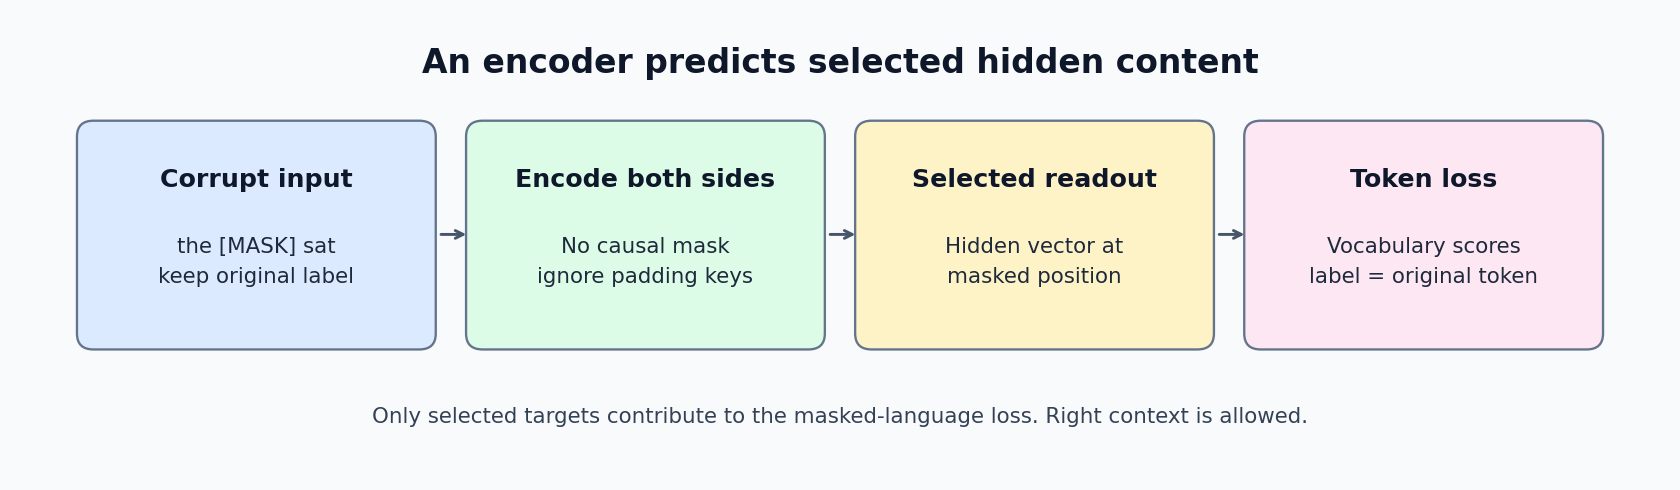

Suppose the original phrase is `the cat sat`. A training example replaces the selected word with a special marker: `the [MASK] sat`. The target remains the original token `cat`.

| Stage | What happens |
| --- | --- |
| Preserve the original target | Store the original ID at the selected position |
| Corrupt the input | Replace selected content according to the masking policy |
| Encode the supplied sequence | Allow valid left and right context |
| Read the selected hidden state | Use the vector at the prediction position |
| Produce vocabulary logits | Score candidate original tokens |
| Compute selected-position loss | Compare with the stored original ID |

The model is not given a human annotation that explains the word's meaning. It receives a prediction objective. Learning to reduce that objective can produce useful contextual features, but their usefulness for a new task still needs evaluation.


## Contrast the visibility rule with a causal model

For `the [MASK] sat`, the masked position can read `the`, its own mask representation, and `sat`. A causal next-token model predicting `cat` from prefix `the` cannot use the later `sat` in the same way.

| Question | Bidirectional masked-token task | Causal next-token task |
| --- | --- | --- |
| Prediction target | Original selected token | Next token after a prefix |
| Right context | May be supplied | Hidden from that prediction |
| Loss positions | Selected prediction positions | Valid next-token positions |
| Natural interface | Understand an available input | Continue an available prefix |

Bidirectional visibility is not leakage when the task explicitly provides both sides. It would violate an online prediction contract if a future observation were unavailable at prediction time.

A causal mask cannot be omitted simply because a layer's class name says “encoder” or “decoder.” Availability is enforced by the actual computation and masks. Conversely, an encoder for a complete sentence does not need a causal mask solely because it operates on an ordered sequence.


## Distinguish selected positions from visibly masked positions

The original BERT recipe selected 15% of eligible tokens for the masked-language objective. Among selected positions, 80% used `[MASK]`, 10% used a random replacement, and 10% retained the original token. All selected positions still had their original IDs as targets. Original BERT also used next-sentence prediction; later encoder designs can use different objectives. See the [original BERT paper](https://arxiv.org/abs/1810.04805).

For 1000 eligible positions, these percentages correspond to expected counts of 150 selected targets, including 120 mask replacements, 15 random replacements, and 15 unchanged selected inputs. Actual sampled counts can vary with the sampling procedure.

A label mask and the presence of `[MASK]` are therefore different concepts. Searching only for mask tokens would omit selected random-replacement and unchanged targets. The companion intentionally uses one explicit mask and one selected target to keep this distinction's simplest case visible.


## Make input IDs, positions, and padding explicit

The companion's token IDs are `[1,3,2,4,0]`, with mask ID 2, pad ID 0, and original selected target ID 5 at index two. The remaining IDs are teaching symbols, not a real tokenizer's assignments.

| Position | Supplied ID | Role in this example | Loss applied? |
| --- | --- | --- | --- |
| 0 | 1 | Visible token | No |
| 1 | 3 | Visible token | No |
| 2 | 2 | Mask marker | Yes, target ID 5 |
| 3 | 4 | Visible right-context token | No |
| 4 | 0 | Padding | No |

An embedding table maps IDs to width-eight content vectors. A learned position table adds a width-eight vector for each stored position. The Boolean padding mask is `[False,False,False,False,True]`.

Original BERT inputs also use special sequence markers and token-type embeddings for segment membership. The tiny companion omits that full input protocol. Its valid demonstration is bidirectional context, padding exclusion, selected-token logits, and gradient flow; it should not be described as a complete recreation of BERT's pretraining system.


## See which input positions a real query can read

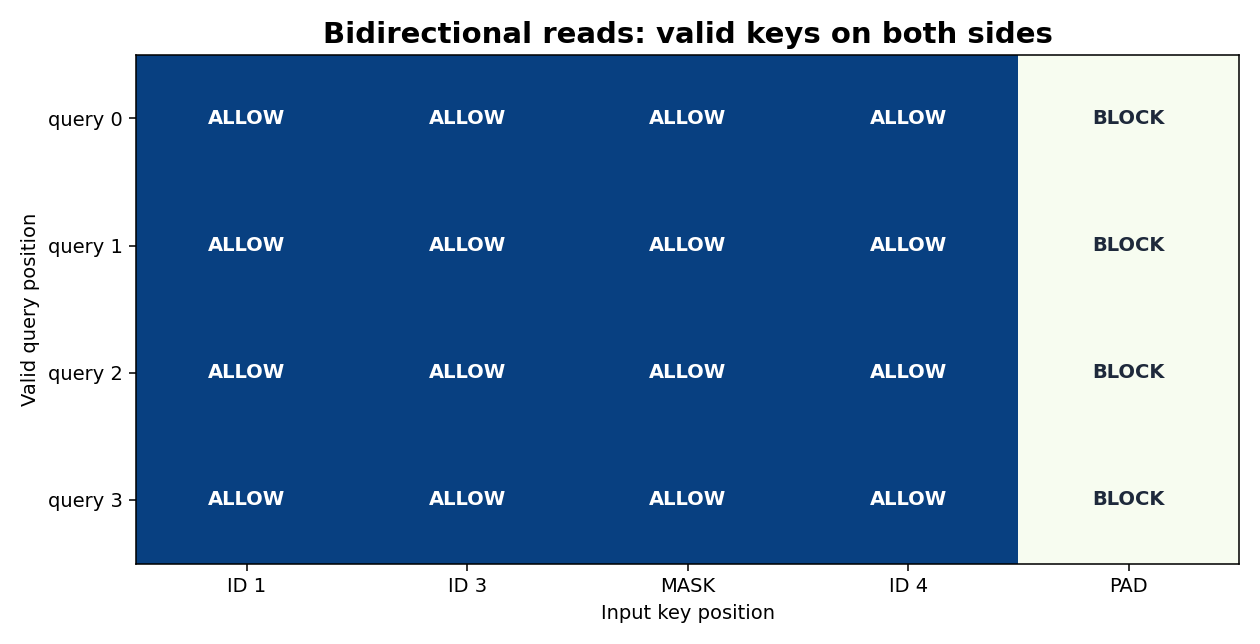

For the four real query positions in the companion, all four real key positions are available. The pad key is blocked. In particular, query index two can read visible right context at index three.

A key-padding mask prevents padding from supplying content; it does not necessarily prevent the layer from computing a vector for a padded query. Padded outputs must also be excluded from loss and summaries when they are not part of the task.

The mask marker itself is a real input representation. It is not padding. It can participate in attention so the selected position has a starting state and position information from which to form its queries.

If an entire real example had no valid keys, the pipeline would need an explicit policy for the empty input. A successful shape allocation alone does not resolve an all-blocked attention row.


## Trace representations to vocabulary logits

The companion uses vocabulary size eight, width eight, two attention heads, FFN width sixteen, and two encoder layers. It disables dropout for this small check.

| Object | Shape |
| --- | --- |
| Token IDs | $(1,5)$ |
| Token and position vectors | $(1,5,8)$ each |
| Padding mask | $(1,5)$ |
| Encoder hidden states | $(1,5,8)$ |
| Vocabulary logits | $(1,5,8)$ |
| Selected-position logits | $(1,8)$ |
| Selected target | $(1,)$ |

The final linear head maps each width-eight hidden vector to eight vocabulary scores. The two eights happen to match, but model width and vocabulary size are distinct design quantities and need not be equal.

The companion computes cross-entropy only from `logits[:, 2]`. Computing a loss on all five positions with ordinary labels would create a different objective and include positions that the example never designated as targets.


## Calculate a masked-token loss with small numbers

For a selected position, consider three candidate-token logits $[0,1,2]$, with the third candidate correct. Stable softmax subtracts the largest score before exponentiation but yields the same probabilities.

| Candidate | Logit | Probability | Target indicator |
| --- | --- | --- | --- |
| A | 0 | 0.090031 | 0 |
| B | 1 | 0.244728 | 0 |
| Correct token | 2 | 0.665241 | 1 |

The loss is $L=-\ln(0.665241)\approx0.407606$. The selected position is uncertain but assigns the largest probability to the correct token.

For a set $S$ of selected positions, a selected-token mean is:

$$L_{MLM}=-\frac1{|S|}\sum_{t\in S}\ln p(x_t\mid \text{corrupted input}).$$

If two selected correct-token probabilities are 0.8 and 0.5, their mean loss is $(-\ln0.8-\ln0.5)/2\approx0.458145$. Dividing by every stored token instead of by selected targets would change the objective's scale with the masking rate or amount of padding.


## Follow a gradient into the vocabulary head

For cross-entropy, the logit derivative is $\partial L/\partial z_j=p_j-\mathbf1[j=y]$. In the three-candidate example, the gradient is approximately $[0.090031,0.244728,-0.334759]$.

To expose one update, treat the logits as head biases with all other contributions fixed. At learning rate 0.1, SGD changes them to about $[-0.009003,0.975527,2.033476]$. The correct-token score increases relative to the other scores, reducing this example's loss.

In a full linear head, each class's weight gradient is its logit derivative multiplied by the incoming hidden vector. The gradient into the hidden state combines the head weights and derivatives. It then passes through encoder layers, attention projections, embeddings, and position parameters.

Only selected positions directly receive vocabulary-loss terms, but other visible positions can still influence them through attention and receive gradients through those paths. “No direct label here” does not mean “this token's representation cannot learn.” The companion checks that the embedding table receives a gradient after its selected-position loss is backpropagated.


## Adapt the encoder with a task-specific readout

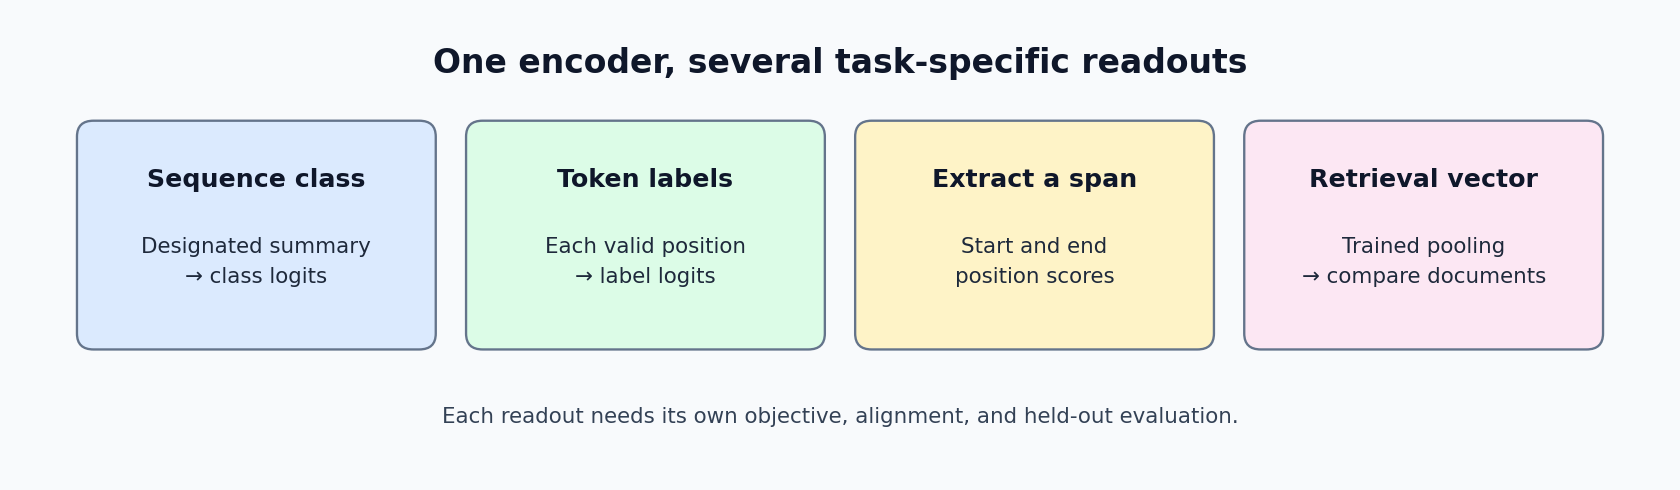

| Task | Readout | Output |
| --- | --- | --- |
| Sequence classification | Designated summary or trained pooling | One distribution over classes |
| Token classification | A head at each relevant position | Position-level label scores |
| Extractive question answering | Start and end scoring heads | Scores over passage positions |
| Retrieval | A trained pooled representation | Vector compared with candidate vectors |

A pretrained encoder provides an initialization or features. Its pretraining objective does not automatically define a document classifier or a high-quality retrieval embedding.

For classification, train the head and whichever backbone parameters the adaptation policy permits. For span extraction, restrict predictions to valid passage positions and enforce meaningful start/end combinations. For retrieval, use a training and evaluation setup that measures relevant-versus-irrelevant candidates, rather than assuming any pooled vector is already calibrated for similarity.

The same encoder architecture can support these interfaces, but the labels, loss, pooling, and evaluation unit differ.


## Align word-level labels to subword tokens

A tokenizer may split a word into several pieces. Suppose a word-level labeling task has words `[playing, outside]`, while a teaching tokenizer produces `[play, ##ing, outside]`.

| Token piece | Word index | First-piece policy | All-piece policy |
| --- | --- | --- | --- |
| play | 0 | Label for playing | Label for playing |
| ##ing | 0 | Ignore | Repeat an appropriate label |
| outside | 1 | Label for outside | Label for outside |

These are different supervision policies. Repeating labels gives split words more loss terms, while first-piece supervision ignores later pieces' direct labels. Entity schemes may require adjusted continuation labels rather than blindly duplicating a beginning tag.

Special markers and padding often need ignored labels too. Keep the tokenizer's alignment mapping rather than reconstructing word positions from string lengths.

Evaluate at the task's actual unit. A token-level accuracy score can look high while entity boundaries are wrong. Aggregate token-piece predictions back to words or spans using a defined rule before reporting a word-level or span-level result.


## Choose between frozen features and fine-tuning

| Adaptation | What learns? | Main practical question |
| --- | --- | --- |
| Frozen backbone | Task head only | Are existing features sufficient? |
| Partial fine-tuning | Head plus selected backbone parameters | Which capacity is worth the budget? |
| Full fine-tuning | Head and full backbone | Can the labeled data support adaptation? |

Freezing parameters and switching to evaluation mode are separate decisions. Freezing controls which parameters get updated; evaluation mode controls behavior such as dropout. A fixed-feature experiment should specify both.

Fit any task preprocessing or label decisions using permitted training data. Select learning rate, training duration, and checkpoint using validation, then assess a held-out test after those choices are made.

Near-duplicate documents or repeated sources can make ordinary random splits overly optimistic. Split according to the intended use: new documents, new users, new sources, or later periods. Pretraining and task adaptation do not remove the need for a valid downstream split.


## Understand the encoder's limits and cost

Bidirectional attention is useful when the input is available in full. It is not an unmodified left-to-right generation procedure: filling selected holes and predicting a next-token distribution under a prefix are different tasks.

Dense source self-attention compares $L^2$ position pairs per head. Longer documents also challenge the position and context policies. Truncating a document may remove the exact passage needed for a label; chunking requires a defined aggregation rule.

A learned contextual representation is not a verified fact database. Pretraining can provide useful patterns, while the downstream model can still fail on a new domain, unfamiliar terminology, ambiguous inputs, or labels defined differently from its training data.

| Limitation | Useful evaluation |
| --- | --- |
| Long-document truncation | Performance by evidence position and length |
| New domain | Held-out domain or source |
| Label imbalance | Per-class errors and meaningful metrics |
| Retrieval mismatch | Ranking on representative queries and candidates |


## Interpret the companion's evidence precisely

The saved companion creates a random tiny encoder, hides one token, supplies a padding mask, computes a selected-position loss, and calls backward. It checks output shape, finite loss, and the existence of an embedding gradient.

There is no optimizer step, repeated training loop, pretrained-weight download, or held-out task evaluation in this notebook. A finite loss establishes that the calculation can be performed; it does not show that the selected token was correctly learned.

To turn the mechanics into a learning experiment, create many independent examples, preserve original selected labels, train with explicit updates, and evaluate on held-out contexts. To study adaptation, start from an actual pretrained encoder and compare frozen-feature and fine-tuning policies under the same task split.

Keep the simple baseline too. For a small classification task, a bag-of-words or linear model may expose whether the contextual machinery adds useful value.


## Diagnose mistakes and practice the objective

| Mistake | First check |
| --- | --- |
| Loss uses the mask ID as the target | Preserve original selected IDs |
| Only visible masks get labels | Selection mask differs from replacement marker |
| Padding enters a sentence summary | Apply valid-position pooling/readout |
| Word labels drift after tokenization | Use piece-to-word alignment |
| Good token accuracy, poor entities | Evaluate complete spans |
| Encoder reused for future prediction | Check actual information availability |

1. Can a visible right-context token affect a masked-token prediction?
2. Does every supplied input position receive a direct MLM loss?
3. In the companion, what ID is predicted at position two?
4. Does a backward pass alone complete training?

**Answers.** Right context is allowed in this task. Only selected target positions receive direct MLM terms. The companion's target is ID five, not mask ID two. Backward computes gradients; an optimizer update and an appropriate training/evaluation process are separate work.

**Remember:** an encoder contextualizes the available input; its objective and head decide what those representations learn to predict. Continue with [GPT and Autoregressive Models](32_GPT_and_Autoregressive_Models_Notes.ipynb) for prefix-only next-token learning.


## Connect this lesson to a trained Transformer

<div style="background:#DBEAFE;border-left:6px solid #2563EB;padding:16px;border-radius:8px"><b>Complete learning experience.</b> The [lesson 32 code project](32_GPT_and_Autoregressive_Models.ipynb) now trains a small causal Transformer, selects a checkpoint on validation sentences, evaluates excluded sentences, compares with a training-only unigram baseline, and generates continuations.</div>

The project uses 256 unique sentences from a controlled combinatorial grammar, split into 192 training, 32 validation, and 32 test documents before encoding. Familiar words appear across splits, but exact sentences do not. This evaluates new combinations from the same grammar rather than general natural-language competence.

| Earlier lesson | Concrete role in the complete project |
|---|---|
| 26: attention | Each query reads a weighted combination of visible values |
| 27: Transformer | Pre-normalized attention and feed-forward residual updates |
| 28: positions | Learned position vectors distinguish token locations |
| 29: multiple heads | Two attention heads inside a width-32 block |
| 30: encoder/decoder | A causal single-stream backbone, without source cross-attention |
| 31: masked prediction | Contrast: this project predicts next tokens, not hidden tokens using both sides |
| 32: autoregression | Shifted targets, repeated optimization, held-out likelihood, and feedback during generation |

Trace one sentence from BOS through embeddings and positions to `[B,L,V]` logits. Then check which targets are excluded, how validation chooses the stored weights, and why generated tokens become part of the next input. A future-token perturbation assertion verifies causal visibility. Sampling excludes invalid special outputs but does not enforce the sentence grammar.
